In [1]:
import random
from value import *

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x): # w * x + b
        # print(list(zip(self.w, x)))
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data: 0.8175465118650015)

In [2]:
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,  x):
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):

        return [p for neuron in self.neurons for p in neuron.parameters()]

        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        #
        # return params

In [3]:
n = Layer(2, 3)
n(x)

[Value(data: -0.9994578018050828),
 Value(data: -0.8328911695988693),
 Value(data: 0.6436609670167877)]

In [4]:
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [5]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data: 0.3036723165561395)

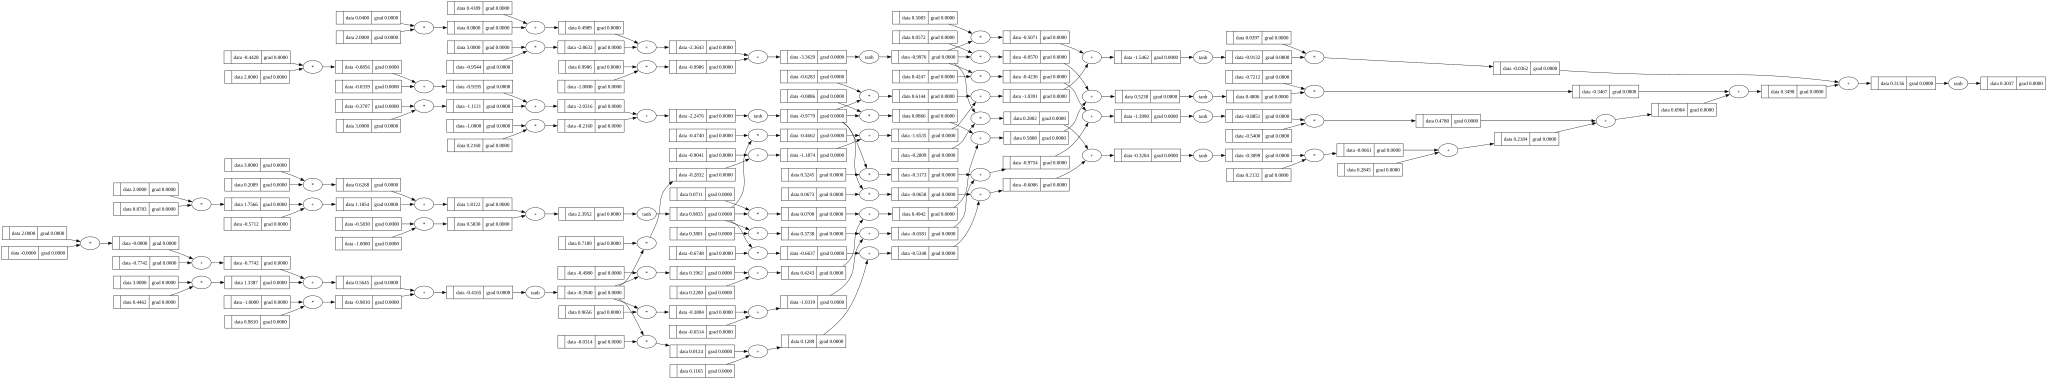

In [6]:
draw_dot(n(x))

In [7]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 0.5, -1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data: 0.3036723165561395),
 Value(data: 0.00495354148259598),
 Value(data: 0.30123098373164076),
 Value(data: 0.2609882708444307)]

In [8]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data: 3.734144272121423)

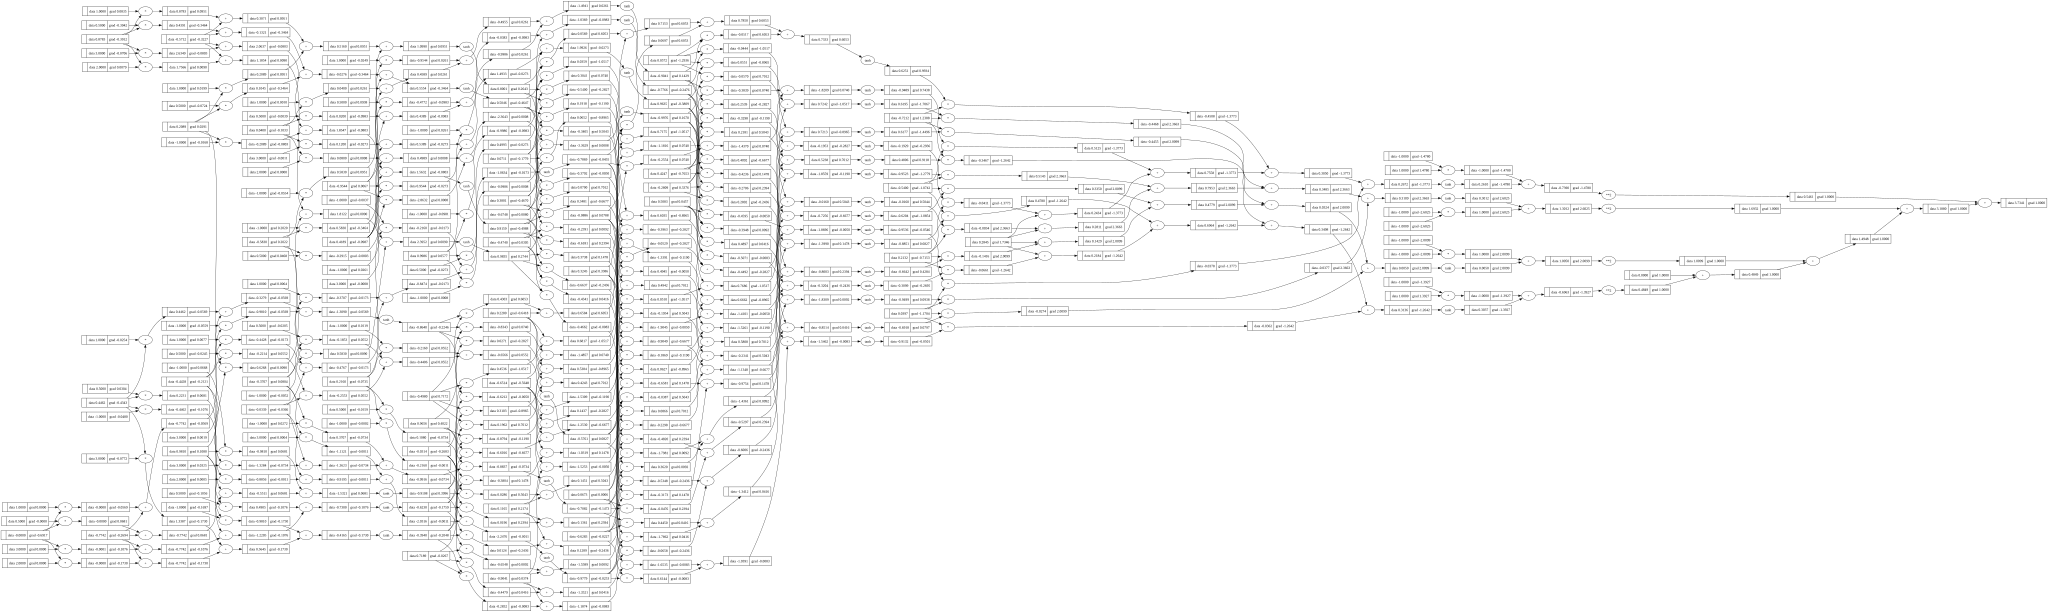

In [9]:
loss.backward()
draw_dot(loss)

In [10]:
n.parameters()

[Value(data: -2.459556784306649e-05),
 Value(data: 0.4462418592640851),
 Value(data: 0.9810196002067291),
 Value(data: -0.774165044978969),
 Value(data: 0.8782990831587414),
 Value(data: 0.20893973104933683),
 Value(data: -0.5830220895547522),
 Value(data: -0.5712406746024319),
 Value(data: -0.44281107999560976),
 Value(data: -0.37069044531165796),
 Value(data: 0.21596065782272467),
 Value(data: -0.033899182785038784),
 Value(data: 0.04000575310330734),
 Value(data: -0.9544117660749956),
 Value(data: 0.9985510121628327),
 Value(data: 0.41889371048006985),
 Value(data: -0.031412923768989076),
 Value(data: -0.6748357363628066),
 Value(data: 0.0672596786271773),
 Value(data: -0.2808629575797339),
 Value(data: 0.1165190417514137),
 Value(data: 0.9655914115417341),
 Value(data: 0.3800655574054548),
 Value(data: 0.32450545434504585),
 Value(data: 0.42466055324983865),
 Value(data: -0.6514325858631311),
 Value(data: -0.4980402609929151),
 Value(data: 0.07113055686566616),
 Value(data: -0.0885

In [11]:
for k in range(200):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0 # important!!!
    loss.backward()

    for p in n.parameters():
        p.data -= 0.005 * p.grad

    print(k, loss.data)

0 3.734144272121423
1 3.671837557446933
2 3.617606172106591
3 3.5693678299135794
4 3.5254096574995675
5 3.4843760268667445
6 3.445226162372812
7 3.4071819722045698
8 3.3696774638320575
9 3.332314841825516
10 3.2948286724990195
11 3.2570575847138072
12 3.21892217083935
13 3.180407569923346
14 3.14154935617307
15 3.102421646703596
16 3.063126683220052
17 3.023785470392065
18 2.9845293263540005
19 2.9454923901336554
20 2.9068052254629237
21 2.8685896670491076
22 2.8309549964298997
23 2.793995441293074
24 2.7577888957465024
25 2.7223966828581525
26 2.68786413679527
27 2.6542217711463767
28 2.6214868160888725
29 2.5896649402523018
30 2.558752013838895
31 2.5287358103367086
32 2.4995975802862613
33 2.4713134598093083
34 2.4438556985548385
35 2.4171937070251097
36 2.391294933080836
37 2.3661255830711547
38 2.341651205666732
39 2.317837157067104
40 2.2946489655572204
41 2.272052611950862
42 2.2500147406605757
43 2.228502814225867
44 2.207485222270037
45 2.186931354130682
46 2.1668116428641344
